In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, chi2

from nltk.stem import SnowballStemmer


# Configurazione grafici
sns.set_theme(style="whitegrid")
%matplotlib inline

In [99]:
TRAIN_FILE = 'winter_project_2026/development.csv'   
EVAL_FILE = 'winter_project_2026/evaluation.csv'     
OUTPUT_FILE = 'winter_project_2026/sample_submission.csv'

dev_df = pd.read_csv(TRAIN_FILE)
eval_df = pd.read_csv(EVAL_FILE)

dev_df.head()

,Id,source,title,article,page_rank,timestamp,label
0,0,AllAfrica.com,OPEC Boosts Nigeria&#39;s Oil Revenue By .82m Bpd,THE Organisation of Petroleum Exporting Countr...,5,2004-09-16 22:39:53,5
1,1,Xinhua,Yearender: Mideast peace roadmap reaches dead-...,Looking back at the major events that took pla...,5,2004-12-17 19:01:14,0
2,2,Yahoo,Battleground Dispatches for Oct. 5 \\n (CQP...,CQPolitics.com - Here are today's Battleground...,5,2006-10-05 18:42:29,0
3,3,BBC,Air best to resuscitate newborns,Air rather than oxygen should be used to resus...,5,0000-00-00 00:00:00,0
4,4,Yahoo,High tech German train crash kills at least on...,"<p><a href=""http://us.rd.yahoo.com/dailynews/r...",5,2006-09-22 17:28:57,0


In [100]:
dev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79997 entries, 0 to 79996
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         79997 non-null  int64 
 1   source     79997 non-null  object
 2   title      79996 non-null  object
 3   article    79996 non-null  object
 4   page_rank  79997 non-null  int64 
 5   timestamp  79997 non-null  object
 6   label      79997 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 4.3+ MB


In [101]:
dev_df.isna().any()

Id           False
source       False
title         True
article       True
page_rank    False
timestamp    False
label        False
dtype: bool

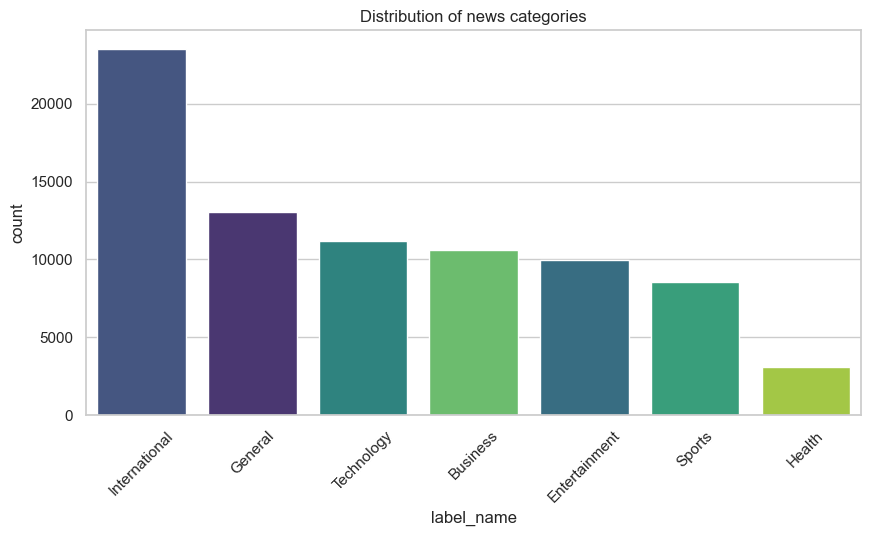

label
0    0.294286
5    0.163169
2    0.139518
1    0.132355
3    0.124717
4    0.107179
6    0.038776
Name: proportion, dtype: float64


In [102]:
# Labels' mapping  
label_map = {
    0: 'International', 1: 'Business', 2: 'Technology', 
    3: 'Entertainment', 4: 'Sports', 5: 'General', 6: 'Health'
}

dev_df['label_name'] = dev_df['label'].map(label_map)

fig = plt.figure(figsize=(10, 5))
sns.countplot(x='label_name', data=dev_df, 
              order=dev_df['label_name'].value_counts().index, 
              palette='viridis', hue='label_name', legend=False)

plt.title("Distribution of news categories")
plt.xticks(rotation=45)

fig.savefig("distribution_news_categories.pdf", bbox_inches="tight") 

plt.show()

print(dev_df['label'].value_counts(normalize=True))

In [103]:
# Gestione testo + selezione feature utili

# Duplicates
duplicates = dev_df.duplicated(subset=['title', 'article']).sum()
print(f"Duplicati trovati (Titolo+Articolo): {duplicates}")

inconsistent = dev_df.groupby(['title', 'article'])['label'].nunique()
print(inconsistent[inconsistent > 1])

# Controllo Lunghezza Testo
dev_df['text_len'] = (dev_df['title'].fillna('') + " " + dev_df['article'].fillna('')).apply(len)
print(f"Articoli con lunghezza 0 o < 50 chars: {(dev_df['text_len'] < 50).sum()}")

def preprocess_text(df, remove_duplicates=False):
    if remove_duplicates:
        initial_len = len(df)
        
        # LOGICA AVANZATA DI GESTIONE DUPLICATI
        if 'label' in df.columns:
            # 1. Calcoliamo la frequenza di ogni label per ogni testo
            # Esempio: "Juve vince" -> Sport (5 volte), Business (1 volta)
            df['count_per_label'] = df.groupby(['title', 'article', 'label'])['title'].transform('count')
            
            # 2. Troviamo la frequenza MASSIMA per quel testo (indipendentemente dalla label)
            # Esempio: Per "Juve vince", il max è 5.
            df['max_count_for_text'] = df.groupby(['title', 'article'])['count_per_label'].transform('max')
            
            # 3. Step Filtro: Teniamo solo le righe che hanno la label vincente (maggioranza)
            # Questo elimina la label "Business" (count 1 < max 5)
            df_majority = df[df['count_per_label'] == df['max_count_for_text']].copy()
            
            # 4. Step Tie-Breaker: Gestione dei Pareggi (es. 1 Sport vs 1 Business)
            # Se dopo il filtro sopra, un testo ha ancora PIÙ di 1 label diversa, significa che c'era un pareggio.
            # Li identifichiamo e li rimuoviamo.
            inconsistent_mask = df_majority.duplicated(subset=['title', 'article'], keep=False)
            ties = df_majority[inconsistent_mask].groupby(['title', 'article'])['label'].nunique()
            ties_indices = ties[ties > 1].index
            
            # Rimuoviamo i testi che sono ancora ambigui (pareggi)
            df_clean = df_majority.set_index(['title', 'article']).drop(index=ties_indices, errors='ignore').reset_index()
            
            # 5. Pulizia Finale: Ora che abbiamo risolto i conflitti, teniamo 1 sola copia per testo
            df = df_clean.drop_duplicates(subset=['title', 'article'], keep='first').copy()
            
            # Rimuoviamo colonne temporanee
            # Nota: le colonne potrebbero non esistere se il df è stato ricreato, ma per sicurezza drop solo se ci sono
            drop_cols = ['count_per_label', 'max_count_for_text']
            df = df.drop(columns=[c for c in drop_cols if c in df.columns])
            
        else:
            # Se non c'è la label (Evaluation set), rimuoviamo duplicati puri
            df = df.drop_duplicates(subset=['title', 'article'], keep='first').copy()

        print(f"Rimossi {initial_len - len(df)} duplicati (Strategia Ibrida: Majority Vote + Tie Removal).")
        
    else:
        df = df.copy()
    
        
    # Feature weighting    
    source_feature = (df['source'].fillna('') + " ") * 3
    title_weighted  = (df['title'].fillna('') + " ") * 2
    # qui ha senso farlo anche per il titolo?
    df['text_combined'] = source_feature + title_weighted + " " + df['article'].fillna('')
    
    # Stemming
    stemmer = SnowballStemmer("english")
    
    def clean(text):
        text = str(text).lower()
        text = html.unescape(text)
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'[^a-z0-9\s$€%£]', ' ', text) # useful symbols for class=business (€,%,$)                  
        text = re.sub(r'\s+', ' ', text).strip()
        return " ".join([stemmer.stem(word) for word in text.split()]) # stemming

    df['clean_text'] = df['text_combined'].apply(clean)
    return df

# def extract_time_features(df):
#     df = df.copy()
#     df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
#     df['hour'] = df['timestamp'].dt.hour.fillna(0)
#     df['day_of_week'] = df['timestamp'].dt.dayofweek.fillna(0)
#     return df

def extract_time_features(df):
    df = df.copy()
    
    # Convertiamo in datetime, gestendo gli errori
    df['timestamp_dt'] = pd.to_datetime(df['timestamp'], errors='coerce')
    
    # 1. Feature Booleana: "Ha una data valida?" (Molto importante per Classe 2 vs 4)
    df['has_date'] = df['timestamp_dt'].notna().astype(int)
    
    # 2. Estraiamo ora e giorno solo dove possibile, altrimenti mettiamo un valore "neutro" (-1)
    # Usiamo -1 così il modello capisce che è diverso da "0" (mezzanotte)
    df['hour'] = df['timestamp_dt'].dt.hour.fillna(-1)
    df['day_of_week'] = df['timestamp_dt'].dt.dayofweek.fillna(-1)
    
    # Rimuoviamo la colonna temporanea dt e quella originale stringa se non serve più
    df = df.drop(columns=['timestamp_dt'])
    
    return df

dev_df = extract_time_features(dev_df)
eval_df = extract_time_features(eval_df) # controlla se va fatto

""" 
    B. Gestione dei Duplicati (Solo nel Training)
    Se nel development.csv  ci sono righe identiche, il modello va in overfitting su quelle frasi. 
    Dobbiamo rimuovere i duplicati dal set di training, ma MAI dal set di evaluation (perché dobbiamo predire per ogni ID richiesto).
"""
dev_df = preprocess_text(dev_df, remove_duplicates=True)
eval_df = preprocess_text(eval_df, remove_duplicates=False) # controlla se va fatto

Duplicati trovati (Titolo+Articolo): 2954
title                                                  article                                                                                                                                                                                                                                         
 Coca-Cola Plans Huge Plant For Stepped-Up Recycling    Coca-Cola said yesterday that it will open a massive recycling plant in Spartanburg, S.C., next year as part of its long-term goal to recycle or reuse all plastic bottles containing its products sold in the United States.                      2
 Google Fourth-Quarter Earnings Nearly Triple           Google reported today that its fourth-quarter profit nearly tripled from a year ago as the world's most popular search engine continued to expand its dominant role on the Web, especially in the highly lucrative area of online advertising.     2
 Head of IMF Stepping Down                              Rodr

cosa comporta avere articoli con lunghezza 0 o <50?

In [104]:
feature_cols = ['clean_text', 'source', 'page_rank', 'hour', 'day_of_week', 'has_date']

X_dev = dev_df[feature_cols]
X_eval = eval_df[feature_cols] # serve?

y_dev = dev_df['label'] 
eval_ids = eval_df['Id'] # sec me, da rimuovere (è solo per la formattazione del csv finale)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.2, random_state=42, stratify=y_dev
)

In [105]:
# Definiamo una pipeline specifica per il testo: TF-IDF -> Selezione Feature
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', min_df=3, sublinear_tf=True)),
    ('selector', SelectKBest(chi2)) # Placeholder, il k verrà deciso dalla GridSearch
])

# Usiamo ColumnTransformer per trattare diversamente testo e numeri

# meglio usare tokenisation per source?
preprocessor = ColumnTransformer(
    transformers=[
        # 1. Ramo Testo
        ('text', text_pipeline, 'clean_text'),
        
        # 2. Ramo Fonte (NUOVO)
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ['source']), # va bene o va usata come token?
        
        # 3. Ramo Numerico
        ('num', StandardScaler(), ['page_rank', 'hour', 'day_of_week', 'has_date'])
    ], 
    remainder='drop' # è giusto?
)

base_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LinearSVC(class_weight='balanced', random_state=42, dual='auto'))
])

PARAM_GRID = {
    'preprocessor__text__tfidf__max_features': [None],  # Proviamo ad aumentare ancora le parole
    'preprocessor__text__tfidf__ngram_range': [(1, 2)],  
    'preprocessor__text__selector__k': [20000, 'all'],       
    'clf__C': [0.2] # Esploriamo intorno a 0.1
}

grid = GridSearchCV(
    base_pipeline, 
    PARAM_GRID, 
    cv=3,                
    scoring='f1_macro',   
    n_jobs=-1,            
    verbose=1
)

grid.fit(X_train, y_train)

print(f"Migliori parametri: {grid.best_params_}")
print(f"Miglior CV F1 Score: {grid.best_score_:.4f}")

# --- 6. VALIDAZIONE SUL SET DI VALIDATION ---
# Usiamo il modello migliore trovato per vedere come va sui dati mai visti (il 20%)
best_model_val = grid.best_estimator_
y_pred_val = best_model_val.predict(X_val)
val_f1 = f1_score(y_val, y_pred_val, average='macro')

print(f"\n>>> REPORT VALIDAZIONE (sul 20% hold-out) <<<")
print(f"Macro F1 Score reale: {val_f1:.4f}")
print(classification_report(y_val, y_pred_val))

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Migliori parametri: {'clf__C': 0.2, 'preprocessor__text__selector__k': 'all', 'preprocessor__text__tfidf__max_features': None, 'preprocessor__text__tfidf__ngram_range': (1, 2)}
Miglior CV F1 Score: 0.7073

>>> REPORT VALIDAZIONE (sul 20% hold-out) <<<
Macro F1 Score reale: 0.7141
              precision    recall  f1-score   support

           0       0.76      0.75      0.76      4509
           1       0.74      0.82      0.78      2042
           2       0.81      0.84      0.83      2155
           3       0.65      0.53      0.58      1818
           4       0.79      0.94      0.86      1677
           5       0.60      0.47      0.53      2352
           6       0.56      0.84      0.67       574

    accuracy                           0.73     15127
   macro avg       0.70      0.74      0.71     15127
weighted avg       0.72      0.73      0.72     15127



In [106]:
# --- 7. ADDESTRAMENTO FINALE (RETRAINING) ---
# Ora che sappiamo quali parametri funzionano meglio, riaddestriamo 
# un modello nuovo su TUTTO il dataset di development (100% dei dati etichettati)
# per avere la massima conoscenza possibile prima della submission.

best_k = grid.best_params_['preprocessor__text__selector__k']
best_ngram = grid.best_params_['preprocessor__text__tfidf__ngram_range'] # controlla se sono corretti
best_C = grid.best_params_['clf__C']

final_text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english', 
        min_df=3, 
        sublinear_tf=True,
        ngram_range=best_ngram
    )),
    ('selector', SelectKBest(chi2, k=best_k))
])

final_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('tfidf', final_text_pipeline, 'clean_text'),
            ('ohe', OneHotEncoder(handle_unknown='ignore'), ['source']), # attenzione al curse of dimensionality
            ('num', StandardScaler(), ['page_rank', 'hour', 'day_of_week', 'has_date'])
        ]
    )),
    ('clf', LinearSVC(
        class_weight='balanced', 
        random_state=42, 
        dual='auto',
        C=best_C
    ))
])

final_pipeline.fit(X_dev, y_dev)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf', ...), ('ohe', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [107]:
# -- 8. GENERAZIONE FILE DI SUBMISSION ---
print(f"Predizione su {len(X_eval)} record di Evaluation...")
y_pred_eval = final_pipeline.predict(X_eval)

submission = pd.DataFrame({
    'Id': eval_ids,
    'Predicted': y_pred_eval
})

# Formattazione corretta CSV: Id, Predicted
submission.to_csv(OUTPUT_FILE, index=False)

print("\n" + "="*40)
print(f"COMPLETATO. File generato: {OUTPUT_FILE}")
print("="*40)
print("Verifica header:")
print(submission.head())

Predizione su 20000 record di Evaluation...

COMPLETATO. File generato: winter_project_2026/sample_submission.csv
Verifica header:
   Id  Predicted
0   0          5
1   1          2
2   2          5
3   3          0
4   4          0
